In [26]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

# Ordered market-reach tiers: low → high
SUCCESS_TIER_ORDER = [0, 1, 2, 3]
SUCCESS_TIER_LABELS = {
    0: "Limited Reach",
    1: "Emerging",
    2: "Market Success",
    3: "High Impact",
}
SUCCESS_TIER_PALETTE = {
    0: "#E74C3C",
    1: "#F39C12",
    2: "#27AE60",
    3: "#8E44AD",
}

PLATFORM_COLORS = {"Windows": "#0078D4", "Mac": "#555555", "Linux": "#FCC624"}

PRICE_RANGE_COLORS = {
    "Free": "#2ECC71",
    "Budget": "#3498DB",
    "Standard": "#F39C12",
    "Premium": "#9B59B6",
    "Luxury": "#E74C3C",
}

MONTH_ORDER = [
    "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]

In [27]:
df = pd.read_csv("../data/processed/steam_games_targets.csv")

df.head()

,appid,name,release_date,developers,publishers,price,genres,categories,tags,supported_languages,achievements,windows,mac,linux,owners_midpoint,success_tier,total_reviews,reception_score
0,496350,Supipara - Chapter 1 Spring Has Come!,2016-07-29,['minori'],['MangaGamer'],5.24,['Adventure'],"['Single-player', 'Steam Trading Cards', 'Stea...","{'Adventure': 27, 'Visual Novel': 19, 'Anime':...",['English'],0,True,False,False,10000.0,0,255,0.988235
1,1034400,Mystery Solitaire The Black Raven,2019-05-06,['Somer Games'],['8floor'],4.99,['Casual'],"['Single-player', 'Family Sharing']","{'Casual': 83, 'Card Game': 52, 'Solitaire': 4...","['English', 'French', 'German', 'Russian']",0,True,True,False,10000.0,0,24,0.875000
2,1934300,Armored Brigade II,2025-04-08,['Veitikka Studios'],['Matrix Games'],35.99,"['Simulation', 'Strategy']","['Single-player', 'Steam Workshop', 'Steam Clo...","{'Simulation': 193, 'Strategy': 186, 'RTS': 16...",['English'],0,True,False,False,10000.0,0,130,0.900000
3,1157670,Hepta Beats,2021-05-07,['Matheus Bigatão'],['Matheus Bigatão'],0.99,"['Casual', 'Indie']","['Single-player', 'Steam Achievements', 'Full ...","{'Precision Platformer': 52, 'Rhythm': 45, 'Mu...","['English', 'French', 'Italian', 'German', 'Sp...",9,True,False,False,10000.0,0,32,0.875000
4,1540330,MUMBA IV: Egypt Jewels,2021-12-13,['Airem'],['Airem'],0.59,"['Action', 'Casual', 'Indie', 'Strategy']","['Single-player', 'Steam Achievements', 'Full ...","{'Casual': 64, 'Action': 51, 'Strategy': 42, '...","['English', 'French', 'Italian', 'German', 'Sp...",100,True,True,True,10000.0,0,25,0.760000


In [28]:
df.shape

(44584, 18)

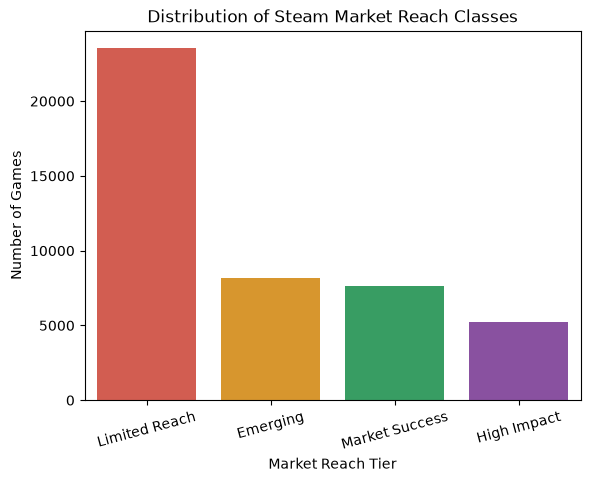

In [29]:
# success tier distribution
tier_palette = [SUCCESS_TIER_PALETTE[t] for t in SUCCESS_TIER_ORDER]

sns.countplot(
    data=df,
    x="success_tier",
    order=SUCCESS_TIER_ORDER,
    palette=tier_palette,
    hue="success_tier",
    legend=False,
)

plt.xticks(
    range(len(SUCCESS_TIER_ORDER)),
    [SUCCESS_TIER_LABELS[t] for t in SUCCESS_TIER_ORDER],
    rotation=15,
)
plt.xlabel("Market Reach Tier")
plt.ylabel("Number of Games")
plt.title("Distribution of Steam Market Reach Classes")
plt.savefig("../reports/figures/success_distribution.png", bbox_inches="tight")

the distribution is imbalanced, so we cannot rely on accuracy, we'll probably use macro f1, confusion matrix


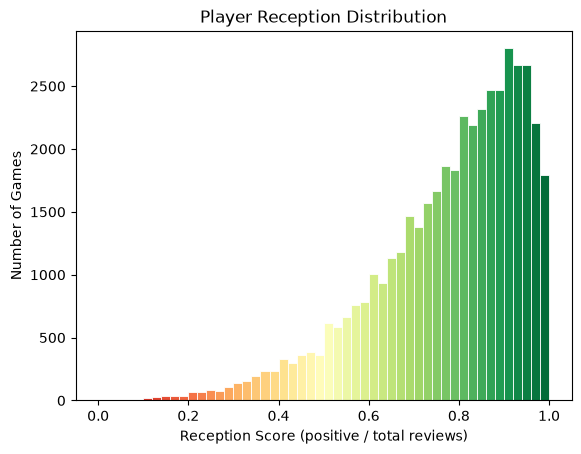

In [30]:
# Reception Distribution
reception = df["reception_score"]
fig, ax = plt.subplots()
counts, bin_edges, patches = ax.hist(
    reception,
    bins=50,
    edgecolor="white",
    linewidth=0.6,
)

cmap = plt.cm.RdYlGn
norm = plt.Normalize(reception.min(), reception.max())
for patch, left, right in zip(patches, bin_edges[:-1], bin_edges[1:]):
    patch.set_facecolor(cmap(norm((left + right) / 2)))

ax.set_xlabel("Reception Score (positive / total reviews)")
ax.set_ylabel("Number of Games")
ax.set_title("Player Reception Distribution")
plt.savefig("../reports/figures/reception_distribution.png", bbox_inches="tight")

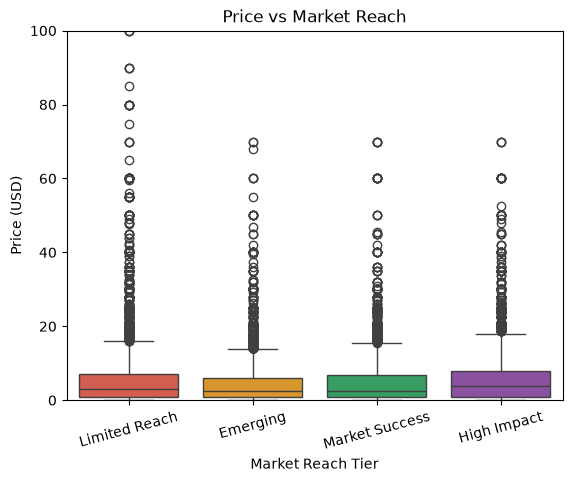

In [31]:
# Price Analysis
tier_palette = [SUCCESS_TIER_PALETTE[t] for t in SUCCESS_TIER_ORDER]

sns.boxplot(
    data=df,
    x="success_tier",
    y="price",
    order=SUCCESS_TIER_ORDER,
    palette=tier_palette,
    hue="success_tier",
    legend=False,
)

plt.xticks(
    range(len(SUCCESS_TIER_ORDER)),
    [SUCCESS_TIER_LABELS[t] for t in SUCCESS_TIER_ORDER],
    rotation=15,
)
plt.ylim(0, 100)
plt.xlabel("Market Reach Tier")
plt.ylabel("Price (USD)")
plt.title("Price vs Market Reach")
plt.savefig("../reports/figures/Price_MarketReach.png", bbox_inches="tight")

In [32]:
# Free vs Paid games

df["is_free"] = df["price"] == 0

df.groupby("is_free")["owners_midpoint"].median()

is_free
False    10000.0
True     35000.0
Name: owners_midpoint, dtype: float64

Text(0.5, 1.0, 'Market Reach by Platform Support')

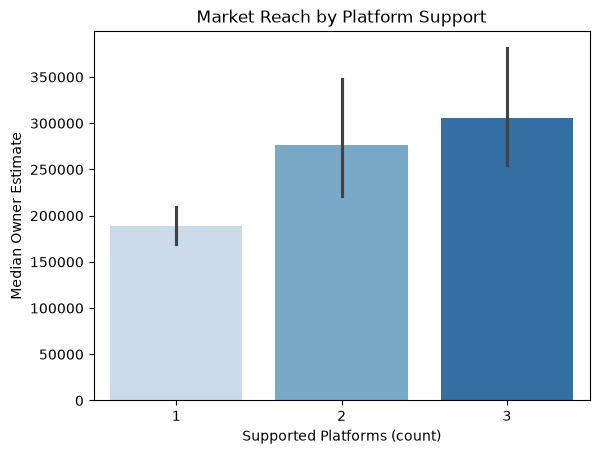

In [33]:
# Platform Count analysis

df["platform_count"] = (
    df["windows"].astype(int) + df["mac"].astype(int) + df["linux"].astype(int)
)

platform_order = sorted(df["platform_count"].unique())
platform_palette = sns.color_palette("Blues", n_colors=len(platform_order))

sns.barplot(
    data=df,
    x="platform_count",
    y="owners_midpoint",
    order=platform_order,
    palette=platform_palette,
    hue="platform_count",
    legend=False,
)

plt.xlabel("Supported Platforms (count)")
plt.ylabel("Median Owner Estimate")
plt.title("Market Reach by Platform Support")

Text(0.5, 1.0, 'Platform Support vs Market Reach')

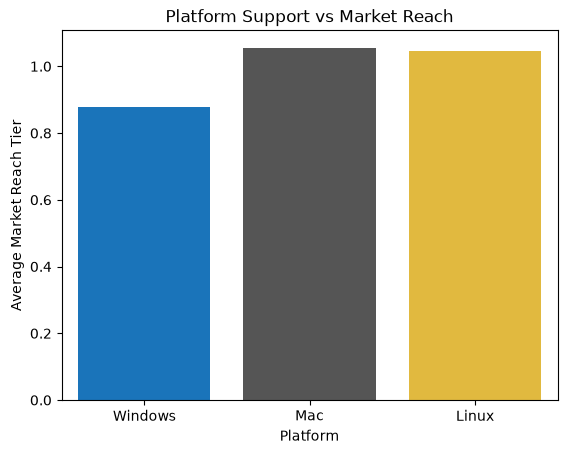

In [34]:
# Platform VS Marker Reach

platform_success = {
    "Windows": df[df["windows"] == True]["success_tier"].mean(),
    "Mac": df[df["mac"] == True]["success_tier"].mean(),
    "Linux": df[df["linux"] == True]["success_tier"].mean(),
}

platforms = list(platform_success.keys())
platform_palette = [PLATFORM_COLORS[p] for p in platforms]

sns.barplot(
    x=platforms,
    y=list(platform_success.values()),
    palette=platform_palette,
    hue=platforms,
    legend=False,
)

plt.xlabel("Platform")
plt.ylabel("Average Market Reach Tier")
plt.title("Platform Support vs Market Reach")

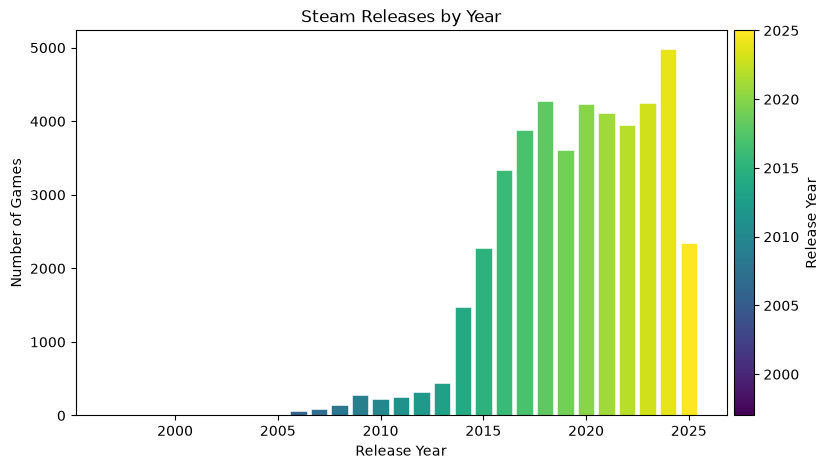

In [35]:
# Release Year Trends
df["release_date"] = pd.to_datetime(df["release_date"])
df["release_year"] = df["release_date"].dt.year

year_counts = df["release_year"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
years = year_counts.index.to_numpy()
counts = year_counts.values
colors = plt.cm.viridis(
    (years - years.min()) / max(years.max() - years.min(), 1)
)

ax.bar(years, counts, color=colors, edgecolor="white", linewidth=0.4)
ax.set_xlabel("Release Year")
ax.set_ylabel("Number of Games")
ax.set_title("Steam Releases by Year")
sm = plt.cm.ScalarMappable(
    cmap=plt.cm.viridis,
    norm=plt.Normalize(years.min(), years.max()),
)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, pad=0.01)
cbar.set_label("Release Year")

plt.savefig("../reports/figures/Release_year.png", bbox_inches="tight")

In [36]:
# Summary Stats

summary_stats = {
    "total_games": len(df),
    "avg_reception": df["reception_score"].mean(),
    "median_price": df["price"].median(),
    "high_impact_rate": (df["success_tier"].eq(3).mean()),
}


summary_stats

{'total_games': 44584,
 'avg_reception': np.float64(0.7758593213876351),
 'median_price': np.float64(2.99),
 'high_impact_rate': np.float64(0.11723936838327652)}

In [37]:
import ast


def parse_list_column(value):

    try:
        return ast.literal_eval(value)

    except:
        return []


df["genres_clean"] = df["genres"].apply(parse_list_column)

df["genres_clean"].head()

0                          [Adventure]
1                             [Casual]
2               [Simulation, Strategy]
3                      [Casual, Indie]
4    [Action, Casual, Indie, Strategy]
Name: genres_clean, dtype: object

In [38]:
# Genre analysis

df["genres"].head()

0                                ['Adventure']
1                                   ['Casual']
2                   ['Simulation', 'Strategy']
3                          ['Casual', 'Indie']
4    ['Action', 'Casual', 'Indie', 'Strategy']
Name: genres, dtype: str

In [39]:
genre_counts = df["genres_clean"].explode().str.strip().value_counts().head(15)


genre_counts

genres_clean
Indie                    31662
Adventure                19077
Action                   18734
Casual                   16240
Simulation               10318
Strategy                  9386
RPG                       9090
Free To Play              3622
Early Access              3504
Sports                    1973
Racing                    1572
Massively Multiplayer     1213
Utilities                  400
Design & Illustration      265
Violent                    216
Name: count, dtype: int64

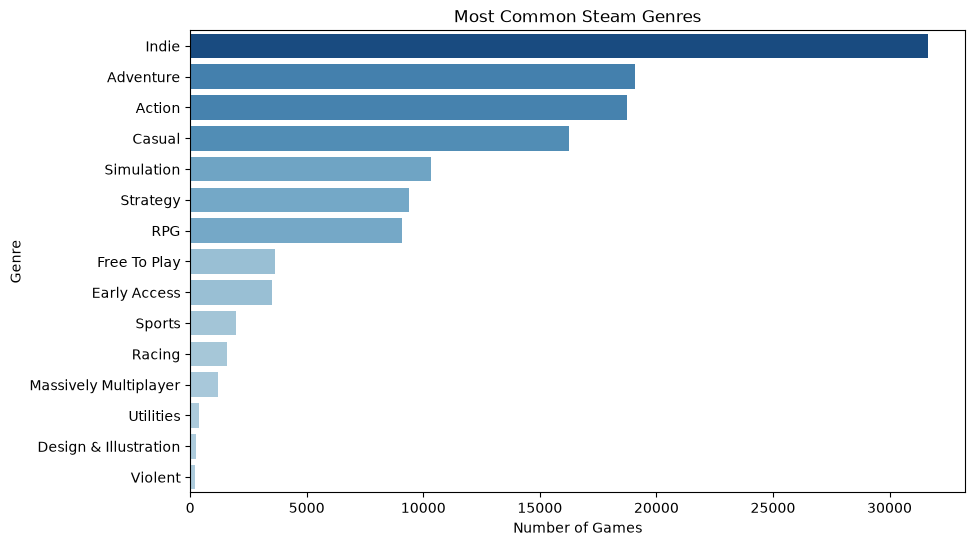

In [40]:
plt.figure(figsize=(10, 6))

genre_palette = [
    plt.cm.Blues(0.35 + 0.55 * (count / genre_counts.max()))
    for count in genre_counts.values
]

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index,
    palette=genre_palette,
    hue=genre_counts.index,
    legend=False,
)

plt.title("Most Common Steam Genres")
plt.xlabel("Number of Games")
plt.ylabel("Genre")
plt.savefig("../reports/figures/top_genres.png", bbox_inches="tight")

In [41]:
# Genre Success rate

genre_df = df.explode("genres_clean")

In [42]:
genre_df = genre_df.rename(columns={"genres_clean": "genre"})

In [43]:
genre_stats = genre_df.groupby("genre").agg(
    avg_success=("success_tier", "mean"), game_count=("name", "count")
)

genre_stats = genre_stats[genre_stats["game_count"] >= 200]

top_success_genres = genre_stats.sort_values("avg_success", ascending=False).head(15)

In [44]:
top_success_genres = genre_stats.sort_values("avg_success", ascending=False).head(15)

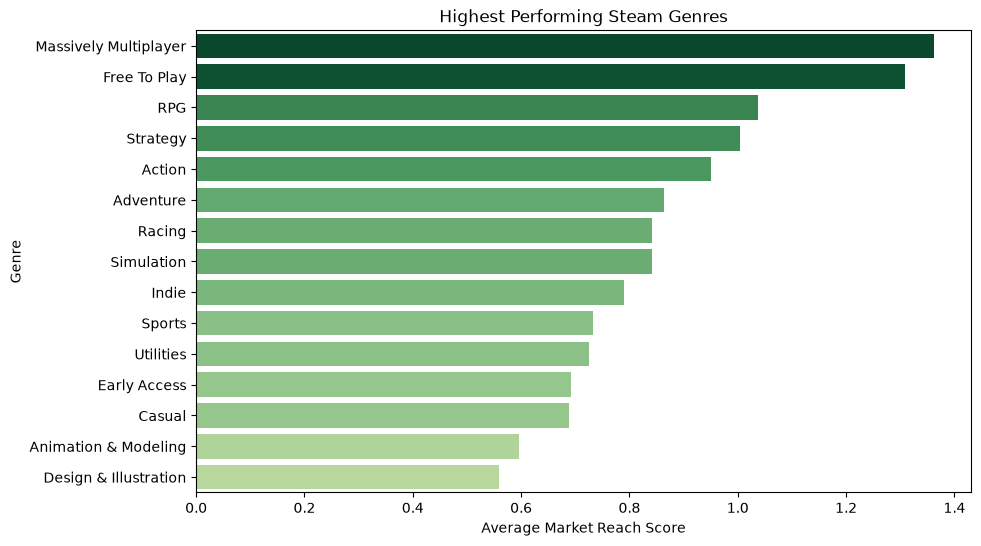

In [45]:
plt.figure(figsize=(10, 6))

success_min = top_success_genres["avg_success"].min()
success_max = top_success_genres["avg_success"].max()
success_range = max(success_max - success_min, 1e-9)

genre_success_palette = [
    plt.cm.YlGn(0.35 + 0.6 * ((score - success_min) / success_range))
    for score in top_success_genres["avg_success"]
]

sns.barplot(
    data=top_success_genres,
    x="avg_success",
    y=top_success_genres.index,
    palette=genre_success_palette,
    hue=top_success_genres.index,
    legend=False,
)

plt.title("Highest Performing Steam Genres")
plt.xlabel("Average Market Reach Score")
plt.ylabel("Genre")
plt.savefig("../reports/figures/genre_success.png", bbox_inches="tight")

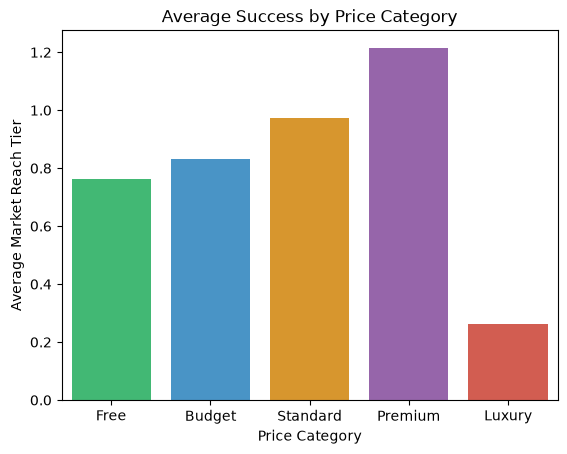

In [46]:
# Price Sweet Spot Analysis

df["price_range"] = pd.cut(
    df["price"],
    bins=[0, 1, 10, 30, 60, 1000],
    labels=["Free", "Budget", "Standard", "Premium", "Luxury"],
)

price_success = df.groupby("price_range", observed=True)["success_tier"].mean()
price_labels = [str(label) for label in price_success.index]
price_palette = [PRICE_RANGE_COLORS[label] for label in price_labels]

sns.barplot(
    x=price_labels,
    y=price_success.values,
    palette=price_palette,
    hue=price_labels,
    legend=False,
)

plt.xlabel("Price Category")
plt.ylabel("Average Market Reach Tier")
plt.title("Average Success by Price Category")
plt.savefig("../reports/figures/Price_SweetSpot.png", bbox_inches="tight")

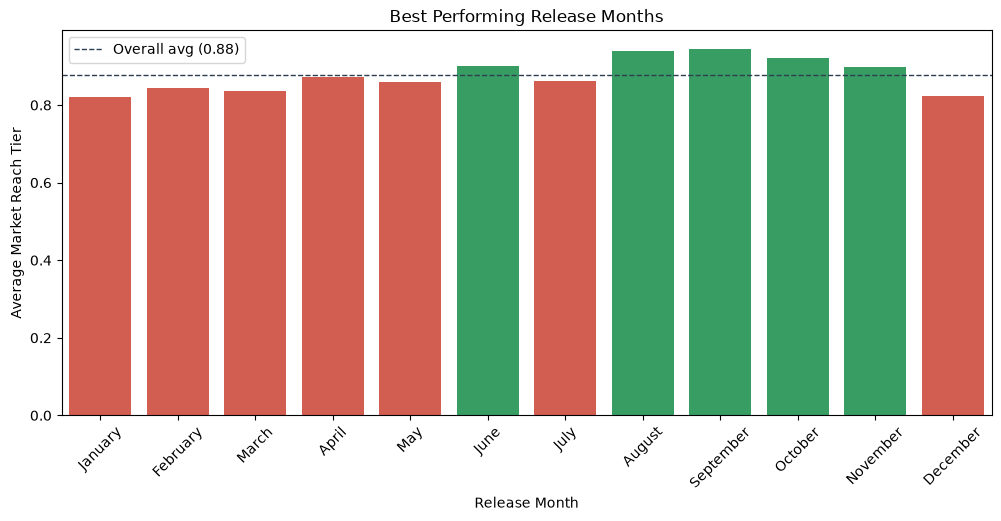

In [47]:
# Release Month Analysis

df["release_month"] = pd.to_datetime(df["release_date"]).dt.month_name()

monthly_success = df.groupby("release_month")["success_tier"].mean().reindex(MONTH_ORDER)
monthly_mean = monthly_success.mean()
month_palette = [
    "#27AE60" if value >= monthly_mean else "#E74C3C"
    for value in monthly_success.values
]

plt.figure(figsize=(12, 5))

sns.barplot(
    x=monthly_success.index,
    y=monthly_success.values,
    palette=month_palette,
    hue=monthly_success.index,
    legend=False,
)

plt.axhline(
    monthly_mean,
    color="#2C3E50",
    linestyle="--",
    linewidth=1,
    label=f"Overall avg ({monthly_mean:.2f})",
)
plt.xticks(rotation=45)
plt.xlabel("Release Month")
plt.ylabel("Average Market Reach Tier")
plt.title("Best Performing Release Months")
plt.legend()
plt.savefig("../reports/figures/Release_month.png", bbox_inches="tight")

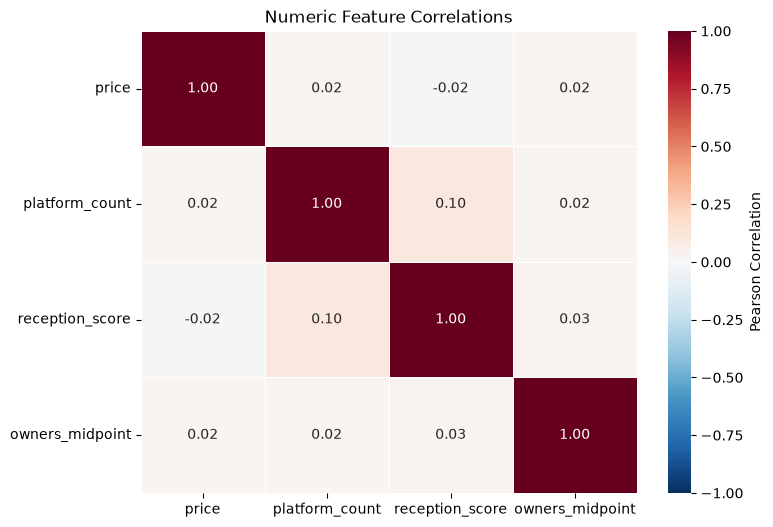

In [48]:
numeric_cols = ["price", "platform_count", "reception_score", "owners_midpoint"]

corr = df[numeric_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    cbar_kws={"label": "Pearson Correlation"},
)

plt.title("Numeric Feature Correlations")
plt.savefig("../reports/figures/Numeric_Corr.png", bbox_inches="tight")